<a href="https://colab.research.google.com/github/P2025046-SCRM/deep-learning-models-training/blob/production-score/Training_Pipeline_InceptionV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Boilerplate to run upon setting the environment again

**Note**: InceptionV3 was trained on 299x299

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import Precision, Recall, AUC, F1Score
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from pathlib import Path

# 1. Defining constants
DRIVE_PATH = '/content/drive/MyDrive/Tesis/preprocessing_data/split_layer2v2'
TRAIN_DIR = f'{DRIVE_PATH}/train'
VAL_DIR = f'{DRIVE_PATH}/val'
TEST_DIR = f'{DRIVE_PATH}/test'

IMG_SIZE = (299, 299)
BATCH_SIZE = 32
NUM_CLASSES = 4 # Your 4 classes
EPOCHS = 10 # This was your original number

# 2. Loading the datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_dataset.class_names

# 3. Optimize pipelines
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Data reloaded successfully. Classes: ", class_names)

Found 521 files belonging to 4 classes.
Found 64 files belonging to 4 classes.
Found 68 files belonging to 4 classes.
Data reloaded successfully. Classes:  ['Biomasa', 'Metales', 'Plastico', 'Retazos']


##Step 1: Install missing packages

In [ ]:
%pip install split-folders

##Step 2: Splitting dataset into train/test/valid subsets:

In [ ]:
import splitfolders

# main dataset path
input_folder = "/content/drive/MyDrive/Tesis/Dataset/Reciclable"

# split dataset output path
output_folder = "/content/drive/MyDrive/Tesis/preprocessing_data/split_layer2v2"

# Split ratios

train = 0.8
valid = 0.1
test = 0.1

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=1337, # For reproducibility
    ratio=(train, valid, test),
    group_prefix=None, # In case of (img, xml) pairs
    move=False # Set to True to move files instead of copying
)

print(f"Data successfully split into {output_folder}")

Copying files: 663 files [02:16,  4.86 files/s]

Data successfully split into /content/drive/MyDrive/Tesis/preprocessing_data/split_layer2


## Step 3: Load datasets

Using Keras to load this split data

In [ ]:
import tensorflow as tf

In [ ]:
# --- 1. Define Constants ---
TRAIN_DIR = '/content/drive/MyDrive/Tesis/preprocessing_data/split_layer2/train'
VAL_DIR = '/content/drive/MyDrive/Tesis/preprocessing_data/split_layer2/val'
TEST_DIR = '/content/drive/MyDrive/Tesis/preprocessing_data/split_layer2/test'

IMG_SIZE = (299, 299) # InceptionV3 default input size
BATCH_SIZE = 32
NUM_CLASSES = 4 # Biomasa, Metales, Plastico, Retazos
EPOCHS = 10

# --- 2. Load the Datasets ---
# Load the raw datasets first
# Resizing will happen *in the model*.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False # Test set wont be shuffled
)

# Get class names
class_names = train_dataset.class_names
print("Classes found by Keras:", class_names)

# --- 3. Optimize Data Pipelines ---
# This pre-fetches data in the background
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

Found 520 files belonging to 4 classes.
Found 63 files belonging to 4 classes.
Found 70 files belonging to 4 classes.
Classes found by Keras: ['Biomasa', 'Metales', 'Plastico', 'Retazos']


## Step 4: Build the model with augmentation on the train dataset

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import Precision, Recall, AUC, F1Score

## Transfer Learning using InceptionV3

### Feature Extraction

In [ ]:
# --- 1. Define Data Augmentation Layers ---
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1),
], name="data_augmentation")

# --- 2. Define InceptionV3 Preprocessing ---
# The *specific* rescaling InceptionV3 expects
preprocess_input = tf.keras.applications.inception_v3.preprocess_input

# --- 3. Load the Base Model (InceptionV3) ---
base_model = tf.keras.applications.InceptionV3(
    include_top=False,  # Remove the final ImageNet classifier
    weights='imagenet',
    input_shape=IMG_SIZE + (3,),
    name="inceptionv3_base"
)

# --- 4. Freeze the Base Model ---
# To avoid re-training the learned ImageNet features
base_model.trainable = False

# --- 5. Chain Everything Together ---
inputs = layers.Input(shape=IMG_SIZE + (3,), name="input_layer")

# 1. Augment (Only during training)
x = data_augmentation(inputs)

# 2. Rescale (Apply InceptionV3's specific preprocessing)
x = preprocess_input(x)

# 3. Run through the frozen base model
x = base_model(x, training=False)

# 4. Add our custom classifier "head"
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(128, activation='relu', name="dense_128")(x)
x = layers.Dropout(0.2, name="dropout")(x) # Regularization
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name="output_layer")(x)

# 6. Create the final model
model = Model(inputs, outputs)

# --- 6. Compile the Model ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    #Metrics to be tracked:
    metrics=[
        'accuracy',  # The classic percentage of correct predictions
        Precision(name='precision'), # How many positive predictions were correct
        Recall(name='recall'),       # How many positive cases did the model find
        AUC(name='auc'),              # Area Under the ROC Curve
        F1Score(average='macro', name='f1_score')
    ]
)

# Let's see the full architecture
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inceptionv3_base (Functional)   │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,572 (84.17 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

##Step 5: Train the model

In [ ]:
print("Starting training.")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset
)

print("Training complete.")

Starting training.
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 333s 19s/step - accuracy: 0.5749 - auc: 0.8039 - f1_score: 0.5652 - loss: 1.0159 - precision: 0.7084 - recall: 0.4238 - val_accuracy: 0.8750 - val_auc: 0.9809 - val_f1_score: 0.8731 - val_loss: 0.3277 - val_precision: 0.8852 - val_recall: 0.8438
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8650 - auc: 0.9757 - f1_score: 0.8657 - loss: 0.3606 - precision: 0.8852 - recall: 0.8349 - val_accuracy: 0.8906 - val_auc: 0.9809 - val_f1_score: 0.8902 - val_loss: 0.3171 - val_precision: 0.9138 - val_recall: 0.8281
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9048 - auc: 0.9870 - f1_score: 0.9036 - loss: 0.2609 - precision: 0.9343 - recall: 0.8869 - val_accuracy: 0.9062 - val_auc: 0.9879 - val_f1_score: 0.9043 - val_loss: 0.2704 - val_precision: 0.9032 - val_recall: 0.8750
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9436 - auc: 0.9947 - f1_score: 0.9343 - loss: 0.1722 - precision: 0.9

## Step 6: Evaluate results

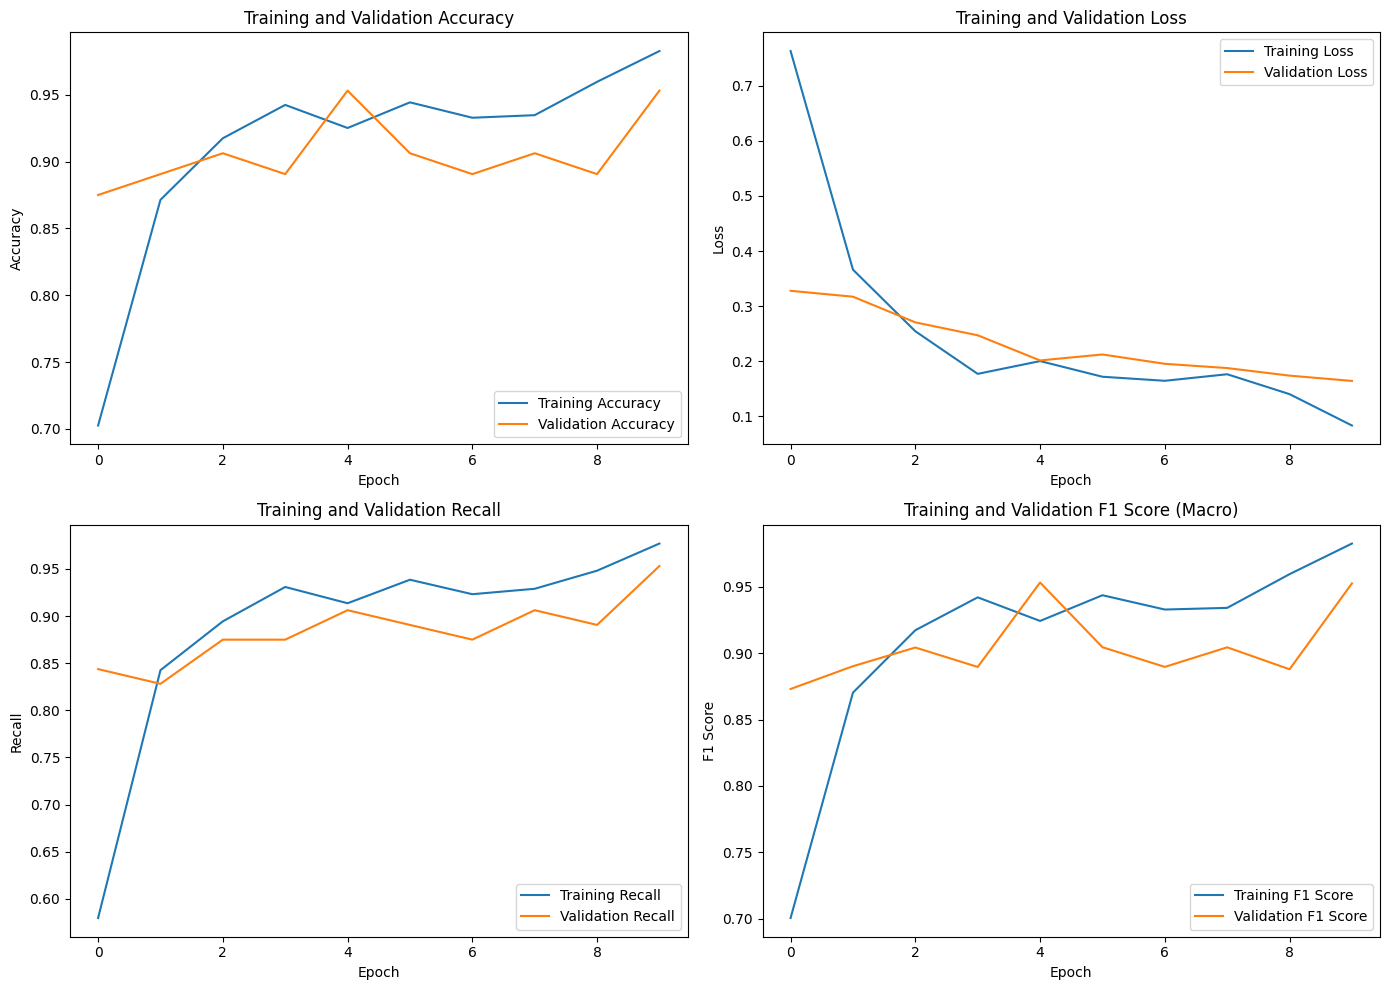

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
recall = history.history['recall']
val_recall = history.history['val_recall']
f1_score = history.history['f1_score']
val_f1_score = history.history['val_f1_score']

epochs_range = range(len(acc))
# --- 2. Create the 2x2 Grid of Plots ---
plt.figure(figsize=(14, 10))

# Plot 1: Accuracy
plt.subplot(2, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot 2: Loss
plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Plot 3: Recall
plt.subplot(2, 2, 3)
plt.plot(epochs_range, recall, label='Training Recall')
plt.plot(epochs_range, val_recall, label='Validation Recall')
plt.legend(loc='lower right')
plt.title('Training and Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')

# Plot 4: F1 Score
plt.subplot(2, 2, 4)
plt.plot(epochs_range, f1_score, label='Training F1 Score')
plt.plot(epochs_range, val_f1_score, label='Validation F1 Score')
plt.legend(loc='lower right')
plt.title('Training and Validation F1 Score (Macro)')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# --- Evaluate on the Test Set ---
print("\nEvaluating on test data...")

# Unpack all 6 values that model.evaluate() is returning
test_loss, test_accuracy, test_precision, test_recall, test_auc, test_f1 = model.evaluate(test_dataset)

# Print all the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test F1 Score (Macro): {test_f1:.4f}")


Evaluating on test data...
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 11s/step - accuracy: 0.9437 - auc: 0.9899 - f1_score: 0.8192 - loss: 0.2091 - precision: 0.9641 - recall: 0.9056
Test Loss: 0.2443
Test Accuracy: 0.9265
Test Precision: 0.9531
Test Recall: 0.8971
Test AUC: 0.9868
Test F1 Score (Macro): 0.9263



Generating final classification report and confusion matrix...
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

Classification Report:
              precision    recall  f1-score   support

     Biomasa       0.80      1.00      0.89        16
     Metales       0.94      1.00      0.97        16
    Plastico       1.00      0.78      0.88        18
     Retazos       1.00      0.94      0.97        18

    accuracy                           0.93        68
   macro avg       0.94      0.93      0.93        68
weighted avg       0.94      0.93      0.93        68

Confusion Matrix:


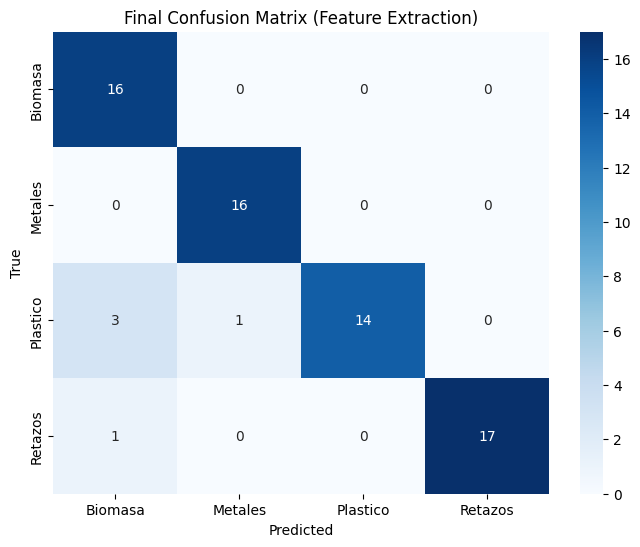

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nGenerating final classification report and confusion matrix...")
predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)

y_true = []
for images, labels in test_dataset.unbatch():
    y_true.append(np.argmax(labels.numpy()))
y_true = np.array(y_true)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Final Confusion Matrix (Feature Extraction)')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_roc_curves(y_true_labels, y_pred_probs, class_names):
    """
    Plots the multi-class ROC curves for a model's predictions.

    Args:
        y_true_labels (array-like): Ground truth labels (as integers, e.g., [0, 1, 3, 2]).
        y_pred_probs (array-like): Model's raw probability predictions (output of model.predict()).
        class_names (list of str): List of class names in order.
    """

    n_classes = len(class_names)

    # --- 1. Binarize the True Labels ---
    # Convert labels from [0, 1, 3, 2] to one-hot encoding
    y_true_binarized = label_binarize(y_true_labels, classes=range(n_classes))

    # --- 2. Calculate ROC curve for each class ---
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # --- 3. Plot all ROC curves ---
    plt.figure(figsize=(10, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(class_names[i], roc_auc[i]))

    # Plot the "random guess" line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc="lower right")
    plt.show()

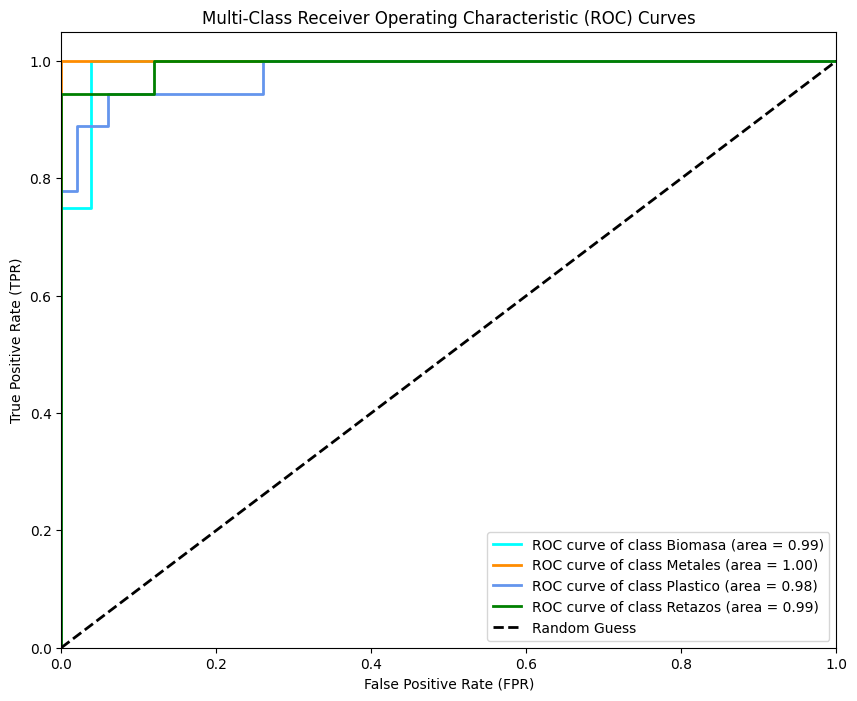

In [ ]:
plot_roc_curves(y_true, predictions, class_names)

## Save base InceptionV3 model v1.0

In [ ]:
model_save_path = '/content/drive/MyDrive/Tesis/Modelo/InceptionV3/inceptionv3_model_1.keras'

In [ ]:
# --- 1. Save Your Model ---

print(f"Saving model to {model_save_path} ...")

# Save the entire model
model.save(model_save_path)

print("Model saved successfully! 💾")

Saving model to /content/drive/MyDrive/Tesis/Modelo/InceptionV3/inceptionv3_model_1.keras ...
Model saved successfully! 💾


Load it back again:

In [ ]:
# --- 2. Load it ---
# Just define and load your data, then run:

from tensorflow.keras.models import load_model

print("Loading model from disk...")
model = load_model(model_save_path)
print("Model loaded.")

model.summary()

Loading model from disk...
Model loaded.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │    262,272 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_128[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 4)         │        516 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,376,078 (92.99 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 525,578 (2.00 MB)

##Step 7: Fine-Tuning Configuration

In [ ]:
#Get the base model
base_model = model.get_layer('inceptionv3_base')

#Unfreeze base model
base_model.trainable = True

#Recompile model with a very low learning rate
#using 1e-5 (0.00001)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        F1Score(average='macro', name='f1_score')
    ]
)
print('\n Model now in fine-tuning mode')
model.summary()


 Model now in fine-tuning mode


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inceptionv3_base (Functional)   │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,572 (84.17 MB)

 Trainable params: 22,031,140 (84.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

##Step 8: Fine-Tuning

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

FINE_TUNE_EPOCHS = 10
# Already trained epochs
initial_epochs = EPOCHS
# How many epochs in total
total_epochs = initial_epochs + FINE_TUNE_EPOCHS

# 1. Early Stopping
# 'patience=3' -> it will stop if val_loss doesn't improve for 3 epochs
# 'restore_best_weights=True' -> it will return the model from the best epoch
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

print("Starting fine-tuning...")

# 2. Continue training the model
history_fine_tune = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=initial_epochs, # Start counting from 10
    validation_data=val_dataset,
    callbacks=[early_stopping] # Add the early stopping callback
)

print("Fine-tuning complete.")

Starting fine-tuning...
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.7807 - auc: 0.9548 - f1_score: 0.7768 - loss: 0.5141 - precision: 0.8061 - recall: 0.7485 - val_accuracy: 0.9375 - val_auc: 0.9956 - val_f1_score: 0.9366 - val_loss: 0.1562 - val_precision: 0.9375 - val_recall: 0.9375
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9000 - auc: 0.9915 - f1_score: 0.8989 - loss: 0.2278 - precision: 0.9224 - recall: 0.8889 - val_accuracy: 0.9062 - val_auc: 0.9920 - val_f1_score: 0.9045 - val_loss: 0.1981 - val_precision: 0.9048 - val_recall: 0.8906
Epoch 13/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9476 - auc: 0.9967 - f1_score: 0.9472 - loss: 0.1447 - precision: 0.9472 - recall: 0.9412 - val_accuracy: 0.9062 - val_auc: 0.9915 - val_f1_score: 0.9045 - val_loss: 0.1979 - val_precision: 0.9062 - val_recall: 0.9062
Epoch 14/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9463 - auc: 0.9939 - f1_score: 0.9461 - loss: 0.1637 - precisi

### Evaluating Final Fine-Tune model

In [ ]:
import matplotlib.pyplot as plt

# --- Evaluate on the Test Set ---
print("\nEvaluating on test data...")

# Unpack all 6 values that model.evaluate() is returning
test_loss, test_accuracy, test_precision, test_recall, test_auc, test_f1 = model.evaluate(test_dataset)

# Print all the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test F1 Score (Macro): {test_f1:.4f}")


Evaluating on test data...
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9056 - auc: 0.9917 - f1_score: 0.7896 - loss: 0.1964 - precision: 0.9056 - recall: 0.9056
Test Loss: 0.2237
Test Accuracy: 0.8971
Test Precision: 0.8971
Test Recall: 0.8971
Test AUC: 0.9901
Test F1 Score (Macro): 0.8956



Generating final classification report and confusion matrix...
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

Classification Report:
              precision    recall  f1-score   support

     Biomasa       0.82      0.88      0.85        16
     Metales       0.84      1.00      0.91        16
    Plastico       1.00      0.78      0.88        18
     Retazos       0.94      0.94      0.94        18

    accuracy                           0.90        68
   macro avg       0.90      0.90      0.90        68
weighted avg       0.91      0.90      0.90        68

Confusion Matrix:


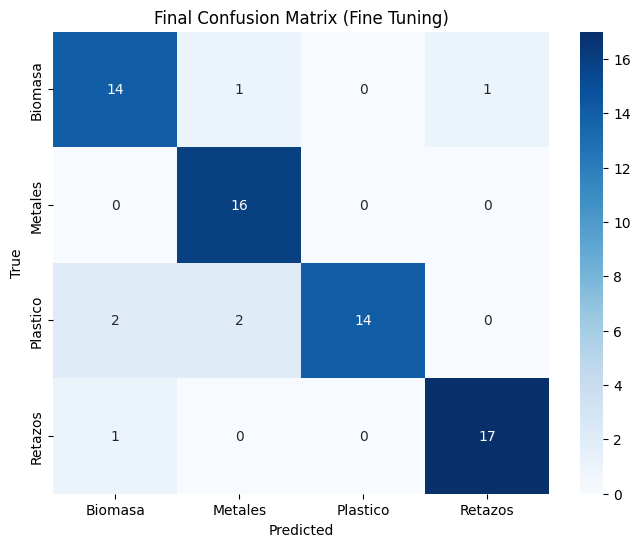

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nGenerating final classification report and confusion matrix...")
predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)

y_true = []
for images, labels in test_dataset.unbatch():
    y_true.append(np.argmax(labels.numpy()))
y_true = np.array(y_true)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Final Confusion Matrix (Fine Tuning)')
plt.show()

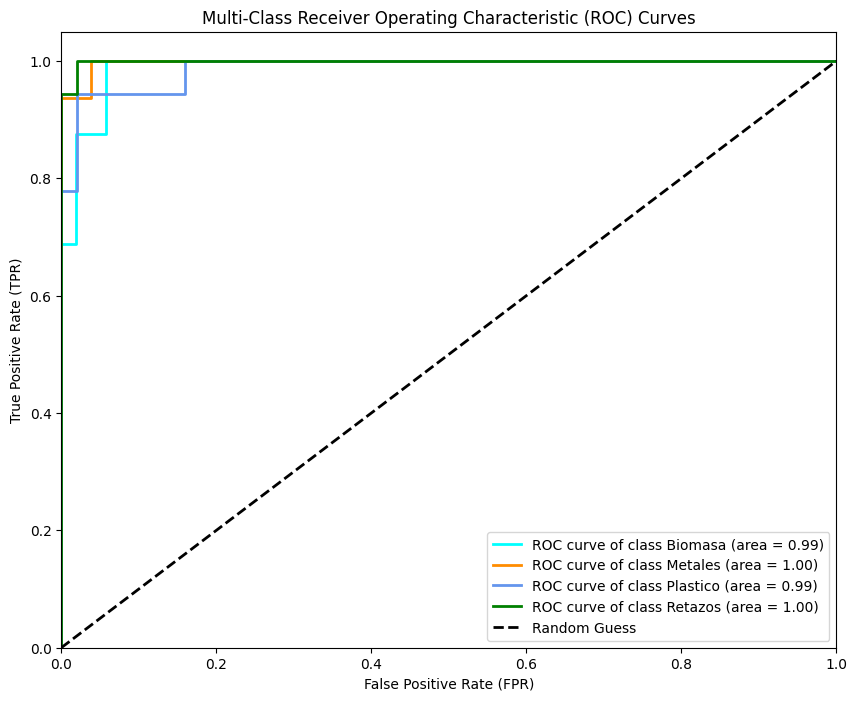

In [ ]:
plot_roc_curves(y_true, predictions, class_names)

Saving for documentation

In [ ]:
save_model_finetune = '/content/drive/MyDrive/Tesis/Modelo/InceptionV3/inceptionv3_model_ft_1.keras'
# --- 1. Save Your Model ---

print(f"Saving model to {save_model_finetune} ...")

# Save the entire model
model.save(save_model_finetune)

print("Model saved successfully! 💾")

Saving model to /content/drive/MyDrive/Tesis/Modelo/InceptionV3/inceptionv3_model_ft_1.keras ...
Model saved successfully! 💾
